<a href="https://colab.research.google.com/github/Muawana038/simulasi-ecg-colab/blob/main/simulasi_ecg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Library berhasil di-import!
Library berhasil di-import!
Fungsi generator ECG siap digunakan.
Fungsi noise siap digunakan.
Fungsi analisis siap digunakan.


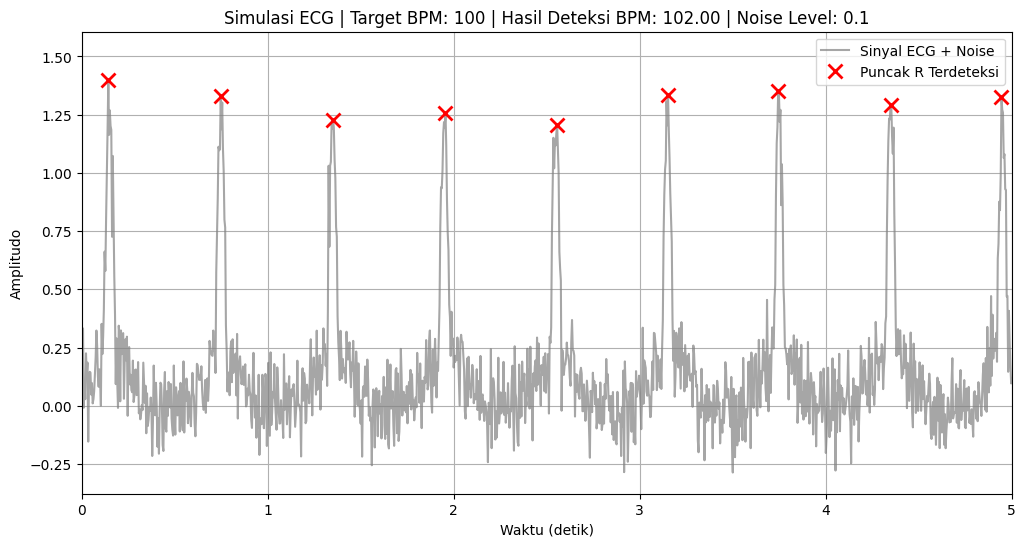

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

print("Library berhasil di-import!")
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

print("Library berhasil di-import!")
def generate_ecg(duration=10, fs=250, bpm=70):
    """
    Fungsi untuk generate sinyal ECG sintetis sederhana.
    duration: durasi dalam detik
    fs: sampling rate (Hz)
    bpm: Beats Per Minute (detak jantung)
    """
    t = np.linspace(0, duration, duration * fs)
    heart_rate_hz = bpm / 60.0

    # Membuat sinyal dasar (detak jantung berkala)
    # Kita gunakan fungsi sinus yang dimodifikasi untuk meniru puncak R yang tajam
    ecg_clean = np.sin(2 * np.pi * heart_rate_hz * t)
    ecg_clean = np.where(ecg_clean > 0.95, (ecg_clean - 0.95) * 20, 0) # Membuat puncak tajam

    # Menambahkan sedikit gelombang P dan T tiruan di sekitar puncak R
    p_wave = 0.1 * np.sin(2 * np.pi * heart_rate_hz * t + 0.5)
    t_wave = 0.15 * np.sin(2 * np.pi * heart_rate_hz * t - 0.5)

    ecg_clean = ecg_clean + np.clip(p_wave, 0, None) + np.clip(t_wave, 0, None)

    return t, ecg_clean

print("Fungsi generator ECG siap digunakan.")
def add_noise(ecg_signal, noise_level=0.1):
    """
    Menambahkan random Gaussian noise ke sinyal ECG.
    noise_level: semakin tinggi nilai, semakin kotor sinyalnya.
    """
    noise = np.random.normal(0, noise_level, len(ecg_signal))
    return ecg_signal + noise

print("Fungsi noise siap digunakan.")
def analyze_ecg(t, ecg_noisy, fs=250):
    # Deteksi puncak R. Nilai height dan distance perlu disesuaikan dengan karakteristik sinyal
    peaks, _ = find_peaks(ecg_noisy, height=0.3, distance=fs/2)

    # Hitung durasi total dalam menit
    total_duration_minutes = (t[-1] - t[0]) / 60.0

    # Hitung BPM berdasarkan jumlah puncak yang terdeteksi
    num_peaks = len(peaks)
    calculated_bpm = num_peaks / total_duration_minutes

    return peaks, calculated_bpm

print("Fungsi analisis siap digunakan.")
# --- PARAMETER YANG BISA KAMU GANTI-GANTI ---
set_bpm = 100       # Target BPM awal
set_noise = 0.1    # Level noise (Coba ganti dari 0.0 sampai 0.8)
# ---------------------------------------------

fs = 250 # Sampling rate
duration = 10 # 10 detik simulasi

# 1. Generate sinyal bersih
t, ecg_clean = generate_ecg(duration=duration, fs=fs, bpm=set_bpm)

# 2. Tambahkan noise
ecg_noisy = add_noise(ecg_clean, noise_level=set_noise)

# 3. Deteksi Peak dan Hitung BPM hasil simulasi
peaks, bpm_result = analyze_ecg(t, ecg_noisy, fs=fs)

# 4. Plot Grafik Hasilnya
plt.figure(figsize=(12, 6))
plt.plot(t, ecg_noisy, label='Sinyal ECG + Noise', color='gray', alpha=0.7)
plt.plot(t[peaks], ecg_noisy[peaks], "x", label='Puncak R Terdeteksi', color='red', markersize=10, mew=2)

plt.title(f"Simulasi ECG | Target BPM: {set_bpm} | Hasil Deteksi BPM: {bpm_result:.2f} | Noise Level: {set_noise}")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.legend(loc="upper right")
plt.grid(True)
plt.xlim(0, 5) # Kita batasi tampilan 5 detik pertama agar terlihat jelas
plt.show()

### Smoothing the ECG Signal with a Butterworth Filter

To achieve a smoother result and potentially improve peak detection in noisy signals, a common technique is to apply a digital filter. Here, we'll use a **Butterworth low-pass filter** from `scipy.signal`. A low-pass filter allows low-frequency components (like the main ECG features) to pass through while attenuating high-frequency noise.

We define a `cutoff_freq` to specify the frequency above which components will be attenuated, and `order` for the filter's steepness. The `filtfilt` function is used for zero-phase filtering, preventing signal distortion.

In [ ]:
from scipy.signal import butter, filtfilt

# --- FILTER PARAMETERS ---
cutoff_freq = 30  # Hz, choose a value appropriate for ECG (e.g., 20-40 Hz)
order = 4         # Filter order (higher order means steeper roll-off)
# --------------------------

# Normalize the cutoff frequency to Nyquist frequency
nyquist_freq = 0.5 * fs
normal_cutoff = cutoff_freq / nyquist_freq

# Get the filter coefficients
b, a = butter(order, normal_cutoff, btype='low', analog=False)

# Apply the filter to the noisy ECG signal
ecg_filtered = filtfilt(b, a, ecg_noisy)

# 3. Deteksi Peak dan Hitung BPM hasil simulasi (menggunakan sinyal yang difilter)
peaks_filtered, bpm_result_filtered = analyze_ecg(t, ecg_filtered, fs=fs)

# 4. Plot Grafik Hasilnya (dengan sinyal yang difilter)
plt.figure(figsize=(14, 7))
plt.plot(t, ecg_filtered, label='Sinyal ECG Filtered', color='blue')
plt.plot(t[peaks_filtered], ecg_filtered[peaks_filtered], "o", label='Puncak R Terdeteksi (Filtered)', color='red', markersize=8)

plt.title(f"Simulasi ECG Filtered | Target BPM: {set_bpm} | Hasil Deteksi BPM (Filtered): {bpm_result_filtered:.2f} | Noise Level: {set_noise}")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.legend(loc="upper right")
plt.grid(True)
plt.xlim(0, 5) # Batasi tampilan 5 detik pertama
plt.show()

print(f"Original BPM: {bpm_result:.2f}")
print(f"Filtered BPM: {bpm_result_filtered:.2f}")